# Practica 04: Análisis de Datos Exploratorio con Python y Jupiter Notebook en un Dataset de Productos de Amazon Store

**Programa de Estudios:** Ingeniería en Entornos Virtuales y Nergocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026


### Unidad 2: Preparación de los Datos

**Nombre del Estudiante:** María del Rosario Maldonado Hilario \
**Matricula:** 230438 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
<h1 style="color: white; font-size: 2.2em; margin: 0;"> 🛒Productos de Amazon Store - Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)</h1>
<p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modeles</p>
</div>

---

## Tabla de Contenidos
| # | Sección | Descripción |
|---|---|---|
|1|[Instalaciones & carga de datos](#s1) |Librerias, carga del CSV, primeros comandos de estructura |
|2|[Diccionario de Datos](#s2) | Explicación del contenido de columnas y calcular el % de datos faltantes |
|3|[Limpieza de Datos](#s3) | Apliacación de de metodos basicos de limpieza(eliminación dupliacados,agrupación y datos nulos)|
|4|[Ingenieria de Caracteristicas](#s4) |Distribución, valores atipicos y pruebas|
|5|[Analisis de Categorias](#s5) |Categorías principales, precio por categoría|
|6|[Análisis de Disponibilidad](#s6) |Patrones del estado de stock|
|7|[Correlación y Análisis Bivariado](#s7) |Mapa de calor, gráficos de dispersión |
|8|[Pruebas de Hipótesis Estadísticas](#s8) |ANOVA, Kruskal-Wallis, Spearman|
|9|[Pruebas de Hipótesis Estadísticas](#s9) |ANOVA, Kruskal-Wallis, Spearman|
|10|[Formulación del Problema de ML](#s10) |Matriz de características, división de entrenamiento/prueba|
|11|[Marco de Selección de Modelos](#s11) |Tabla de comparación de modelos, métricas|
|12|[Modelos de Regresión](#s12) |5 modelos entrenados y evaluados|
|13|[Ajuste de Hiperparámetros](#s13) |GridSearchCV en el mejor modelo|
|14|[Comparación de Modelos](#s14) |Resultados comparativos, importancia de las características|
|15|[Conclusiones Clave e Informe](#s15) |Hallazgos comerciales, recomendaciones|
|16|[Conclusión ](#s16) |Conclusiones finales de la práctica|

### 1. Instalaciones & Carga de Datos.  <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px00; color: #0066cc;">
<b>Dataset:</b> Amazon India Listas de Prductos - 1,436 productos entre Libros, Kindle, Deportes & más<br>
<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y diponibilidad<br>
<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in
</div>

In [1]:
# =================================================================
# SECTION 1 - Setup & Data Loading
# =================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

#ML - Machine Learning - Entrenamiento de modelos matemáticos para predecir en este cvaso precios
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'✅ Pandas  : {pd.__version__}')
print(f'✅ NumPy   : {np.__version__}')
print('✅ Todas la librerías cargaron con éxito!')

✅ Pandas  : 2.3.3
✅ NumPy   : 2.3.5
✅ Todas la librerías cargaron con éxito!


In [2]:
# Load dataset
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')
print(f'📦 Shape   : {df_raw.shape}')
print(f'📋 Columns : {df_raw.columns.tolist()}')
df_raw.head(3)

📦 Shape   : (1445, 17)
📋 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


### 2. Diccionario de Datos del Data Frame. <a id='s2'></a>

In [5]:
# Column dictionary
col_info = {
    'rl'              : 'URL del Producto en Amazon.in',
    'asin'             : 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name'             : 'Nombre o Título del Producto',
    'overview'         : 'Breve Reseña del Prodcuto (mayoría vacío [])',
    'price'            : 'Precio como string (e.g. "1,600.00")',
    'currency'         : 'Código de Divisa (todas en INR)',
    'availability'     : 'Texto del Status del Stock (Inventario)',
    'brand'            : 'Nombre de la Marca/Autor ',
    'about_item'       : 'Detalles/Especificaciones (mayoría faltante)',
    'img_source'       : 'URLs de Imágenes del Producto',
    'description'      : 'Descripción detalla y completa (mayoría faltante)',
    'specifications'   : 'Especificaciones Técnicas',
    'primary_category' : 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1'       : 'Subcategoría de nivel 1',
    'category_2'       : 'Subcategoría de nivel 2',
    'category_3'       : 'Subcategoría de nivel 3',
    'breadcrumbs'      : 'Ruta de Categorías'
}

print('📖 Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f'{col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
    )

📖 Diccionario por columnas:
rl                   | URL del Producto en Amazon.in                 | Missing: 0%
asin                 | Número Estandarizado de Identificación por Am | Missing: 0%
name                 | Nombre o Título del Producto                  | Missing: 0%
overview             | Breve Reseña del Prodcuto (mayoría vacío [])  | Missing: 0%
price                | Precio como string (e.g. "1,600.00")          | Missing: 24%
currency             | Código de Divisa (todas en INR)               | Missing: 24%
availability         | Texto del Status del Stock (Inventario)       | Missing: 33%
brand                | Nombre de la Marca/Autor                      | Missing: 1%
about_item           | Detalles/Especificaciones (mayoría faltante)  | Missing: 92%
img_source           | URLs de Imágenes del Producto                 | Missing: 0%
description          | Descripción detalla y completa (mayoría falta | Missing: 93%
specifications       | Especificaciones Técnicas      

### 3. Limpieza de Datos <a id='s3'></a>

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Pareseas el precio strings como "1,600.00" -> float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [7]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,098 / 1,445 products
✅ Duplicate ASINs: 8
✅ Availability categories: {'In Stock': 607, 'Unknown': 481, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 82, 'Other': 23, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


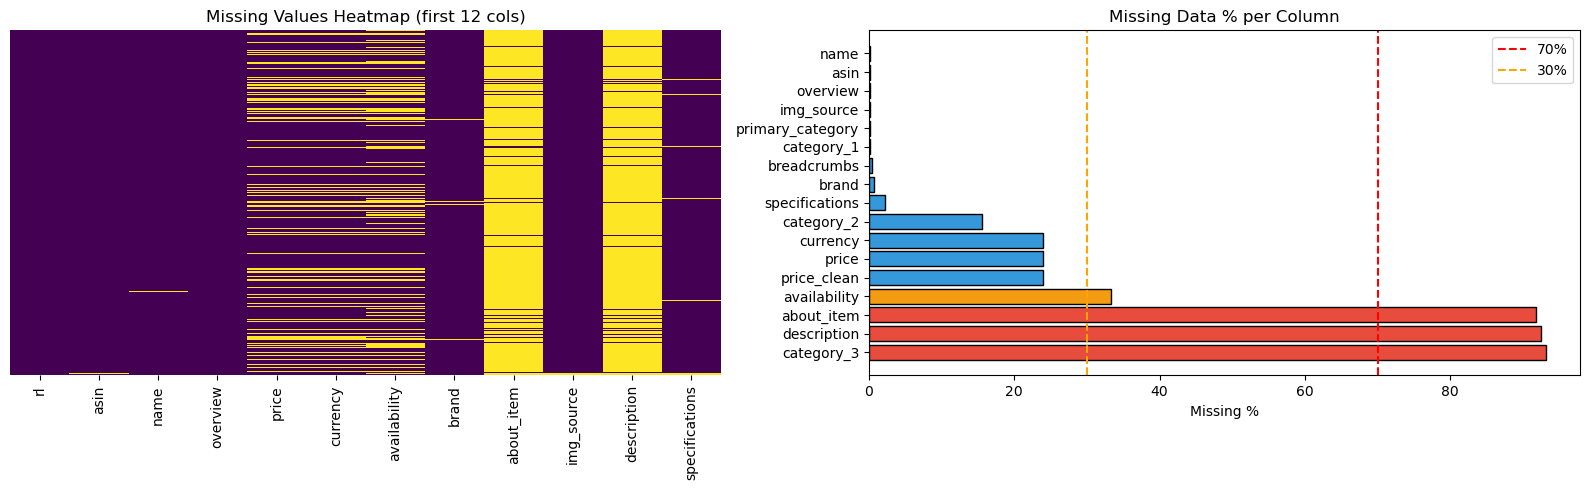

                  Missing Count  Missing Pct
category_3                 1347         93.2
description                1337         92.5
about_item                 1326         91.8
availability                481         33.3
price_clean                 347         24.0
price                       346         23.9
currency                    346         23.9
category_2                  224         15.5
specifications               32          2.2
brand                        10          0.7
breadcrumbs                   6          0.4
category_1                    3          0.2
primary_category              3          0.2
img_source                    3          0.2
overview                      3          0.2
asin                          1          0.1
name                          1          0.1


In [8]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[df.columns[:12]].isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]
axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')
axes[1].set_xlabel('Missing %'); axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout(); plt.show()
print(missing[missing['Missing Count'] > 0].to_string())

### 4. Ingeniería de Características (feature Enginering) <a id='s4'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antigüedad y el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías..
</div>

In [9]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total Características (Atributos) Procesadas (Features Engineering): {len(df.columns)}')
print('\nPrecio para cada tipo (tier) de distribucion:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total Características (Atributos) Procesadas (Features Engineering): 39

Precio para cada tipo (tier) de distribucion:
price_tier
1_budget     106
2_low        285
3_mid        319
4_premium    262
5_luxury     126
Unknown      347


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


### 5. Análisis univariado  <a id='s5'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Cómo es la distribución de precios? ¿Hay valores atípicos? ¿Los datos están sesgados?precio?
</div>

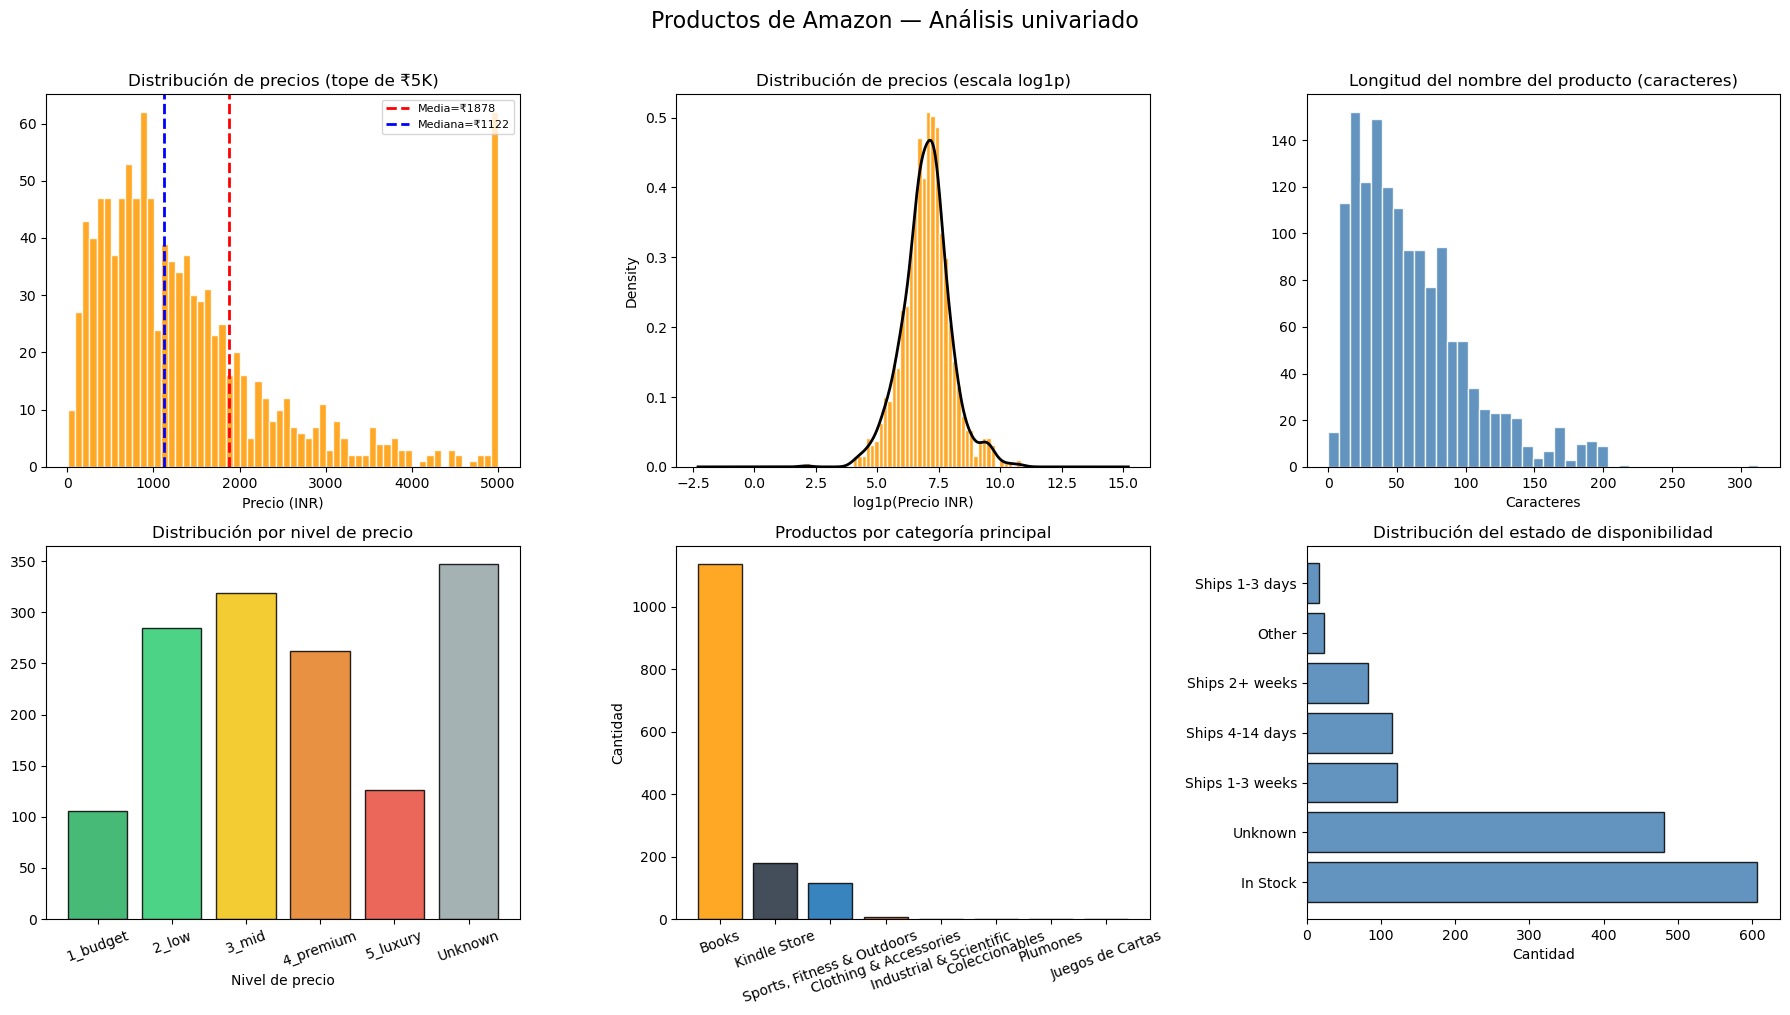

Shapiro-Wilk (precio logarítmico, n=500): estadístico=0.9802, p=0.000003
El precio sigue teniendo una distribución no normal después de la transformación logarítmica

Estadísticas de precios (INR):
Cantidad           1091.00
Media              1878.24
Desv. Estándar     3334.37
Mín                   7.00
25%                 610.50
50%                1122.00
75%                1850.00
Máx               50555.00


In [10]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
from scipy.stats import shapiro  # Aseguramos la importación para evitar el NameError

df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Media=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Mediana=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Distribución de precios (tope de ₹5K)')
axes[0,0].set_xlabel('Precio (INR)'); axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Distribución de precios (escala log1p)')
axes[0,1].set_xlabel('log1p(Precio INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Longitud del nombre del producto (caracteres)')
axes[0,2].set_xlabel('Caracteres')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Distribución por nivel de precio')
axes[1,0].set_xlabel('Nivel de precio'); axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Productos por categoría principal')
axes[1,1].set_ylabel('Cantidad'); axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Distribución del estado de disponibilidad')
axes[1,2].set_xlabel('Cantidad')

plt.suptitle('Productos de Amazon — Análisis univariado', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Test de normalidad (Traducción de los resultados en consola)
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (precio logarítmico, n=500): estadístico={stat:.4f}, p={p:.6f}')
print(f'El precio {"tiene una distribución normal después de la transformación logarítmica" if p > 0.05 else "sigue teniendo una distribución no normal después de la transformación logarítmica"}')

print(f'\nEstadísticas de precios (INR):')
# Traducimos los índices por defecto de .describe() al español
stats_es = df_priced['price_clean'].describe().round(2)
stats_es.index = ['Cantidad', 'Media', 'Desv. Estándar', 'Mín', '25%', '50%', '75%', 'Máx']
print(stats_es.to_string())

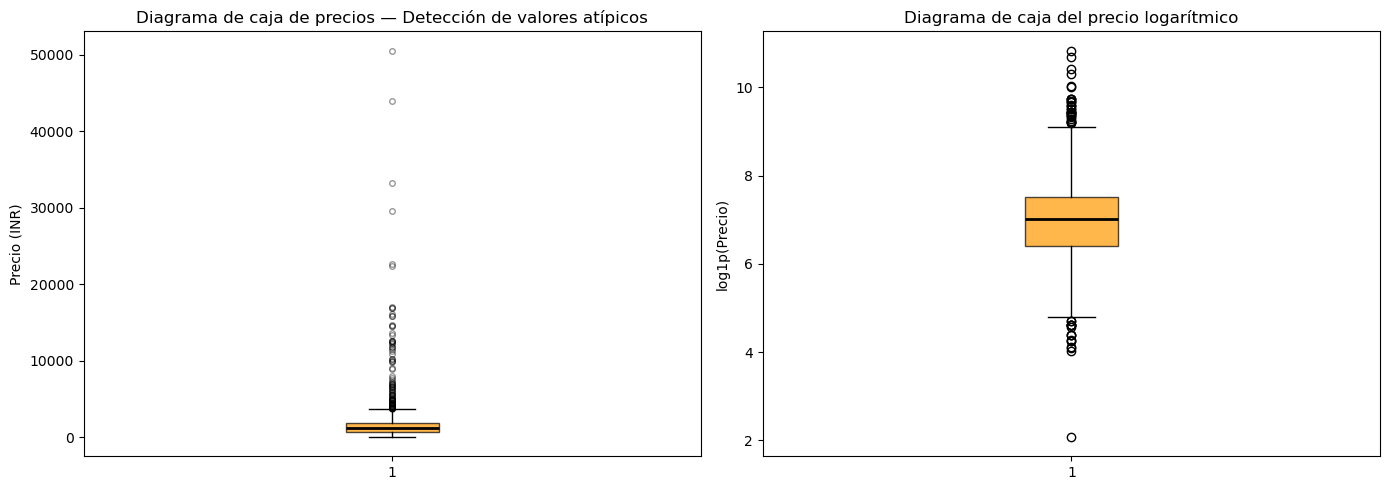

Valores atípicos por el método IQR: 93 (8.5%)
Rango de precio (sin valores atípicos): ₹-1249 – ₹3709

Los 10 productos más caros:
                                                                                                                                      Nombre  Precio (INR)        Categoría Principal
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032      50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications      43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)      33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)  

In [11]:
# Outlier analysis — boxplot and IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Diagrama de caja de precios — Detección de valores atípicos')
axes[0].set_ylabel('Precio (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Diagrama de caja del precio logarítmico')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout(); plt.show()

# Cálculo del IQR y valores atípicos
Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]

# Salidas de consola traducidas
print(f'Valores atípicos por el método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Rango de precio (sin valores atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')

print(f'\nLos 10 productos más caros:')
# Filtramos el top 10, renombramos las columnas para el print y lo mostramos
top_10 = df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].copy()
top_10.columns = ['Nombre', 'Precio (INR)', 'Categoría Principal']
print(top_10.to_string(index=False))

### 6. Análisis de categorías  <a id='s6'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra la mejor relación calidad-precio?
</div>

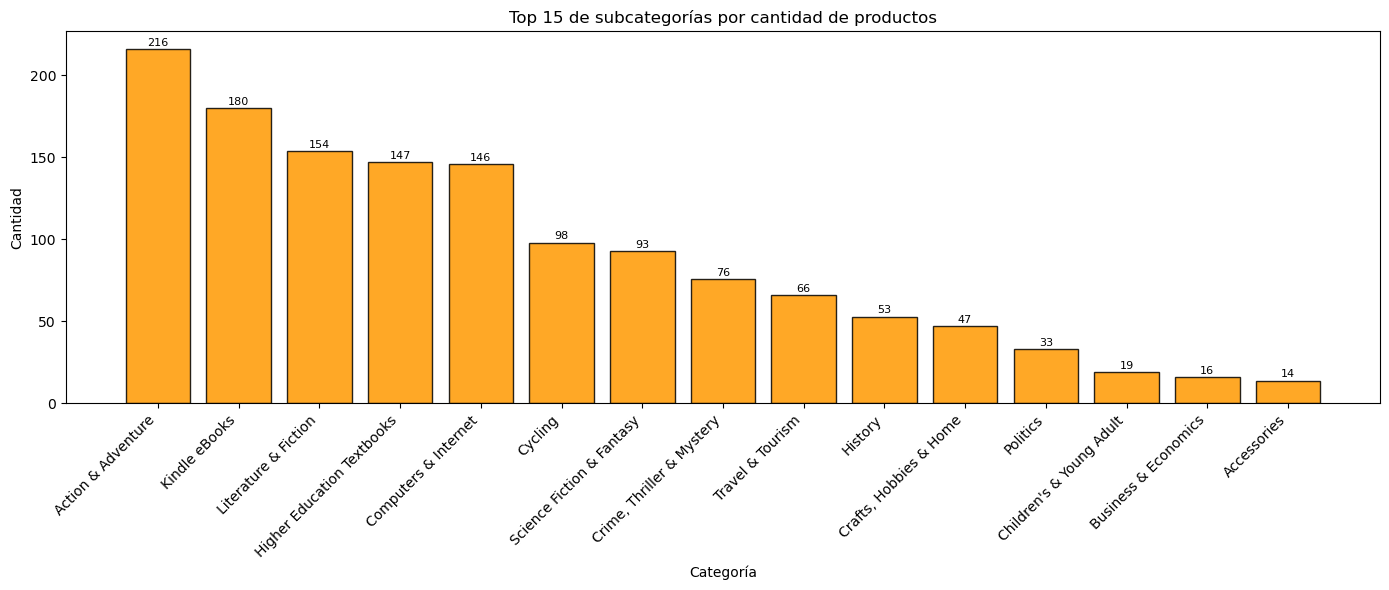

In [12]:
# ============================================================
# SECTION 5 — Category Analysis
# ============================================================
# Top 15 sub-categories by count
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)

for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)

# Textos de la gráfica traducidos al español
plt.title('Top 15 de subcategorías por cantidad de productos')
plt.xlabel('Categoría'); plt.ylabel('Cantidad')

plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

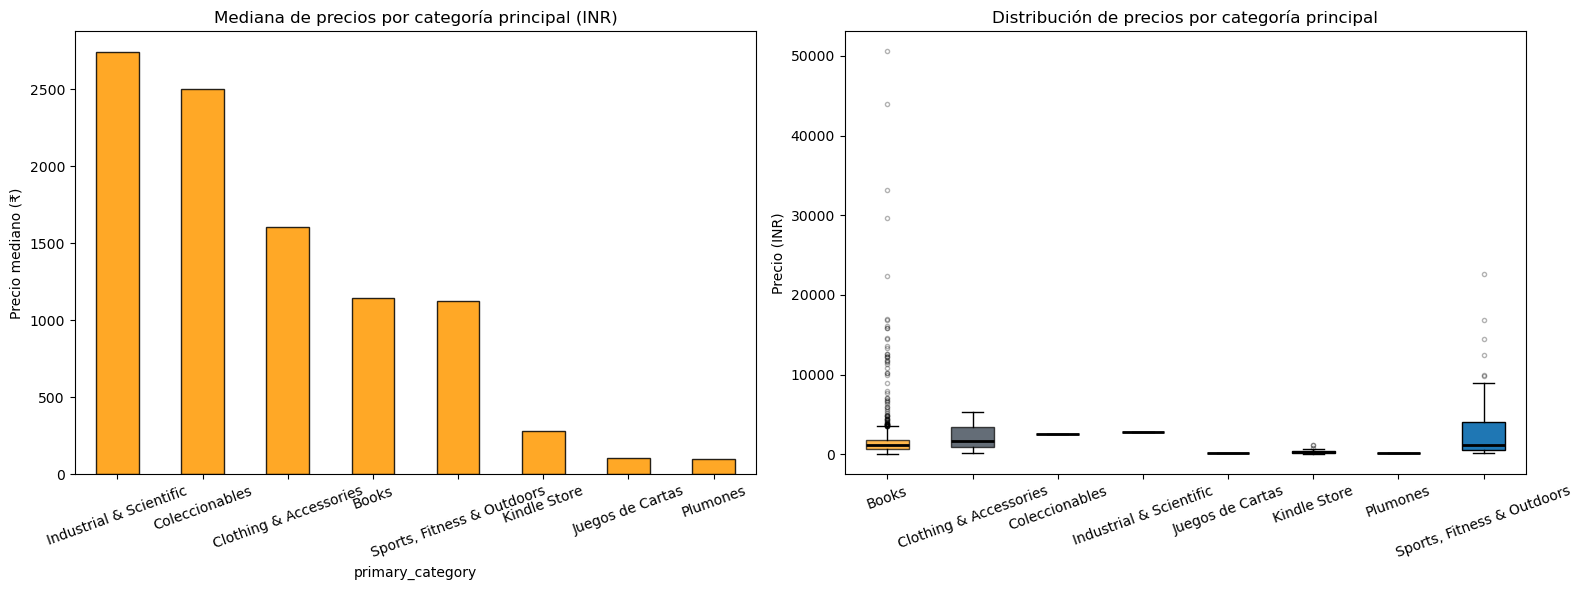

Estadísticas de precios por categoría principal:
                             Media  Mediana  Cantidad
Categoría Principal                                  
Books                       1826.2   1145.0       956
Clothing & Accessories      2249.2   1606.5         6
Coleccionables              2500.0   2500.0         1
Industrial & Scientific     2738.0   2738.0         1
Juegos de Cartas             109.0    109.0         1
Kindle Store                 350.0    281.4        30
Plumones                      99.0     99.0         1
Sports, Fitness & Outdoors  2907.9   1125.0        93


In [13]:
# Price by primary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)

# Gráfico de barras de la mediana
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Mediana de precios por categoría principal (INR)')
axes[0].set_ylabel('Precio mediano (₹)'); axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]
# REEMPLAZADO 'labels' POR 'tick_labels' PARA EVITAR LA ADVERTENCIA DE MATPLOTLIB
bp = axes[1].boxplot(cat_groups, tick_labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)

axes[1].set_title('Distribución de precios por categoría principal')
axes[1].set_ylabel('Precio (INR)'); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.show()

# Salida de la consola traducida al español
print('Estadísticas de precios por categoría principal:')
cat_price_es = cat_price.copy()
# Traducimos los nombres de las columnas estadísticas
cat_price_es.columns = ['Media', 'Mediana', 'Cantidad']
# Opcional: si quieres traducir el nombre del índice que agrupa las categorías
cat_price_es.index.name = 'Categoría Principal'
print(cat_price_es.to_string())

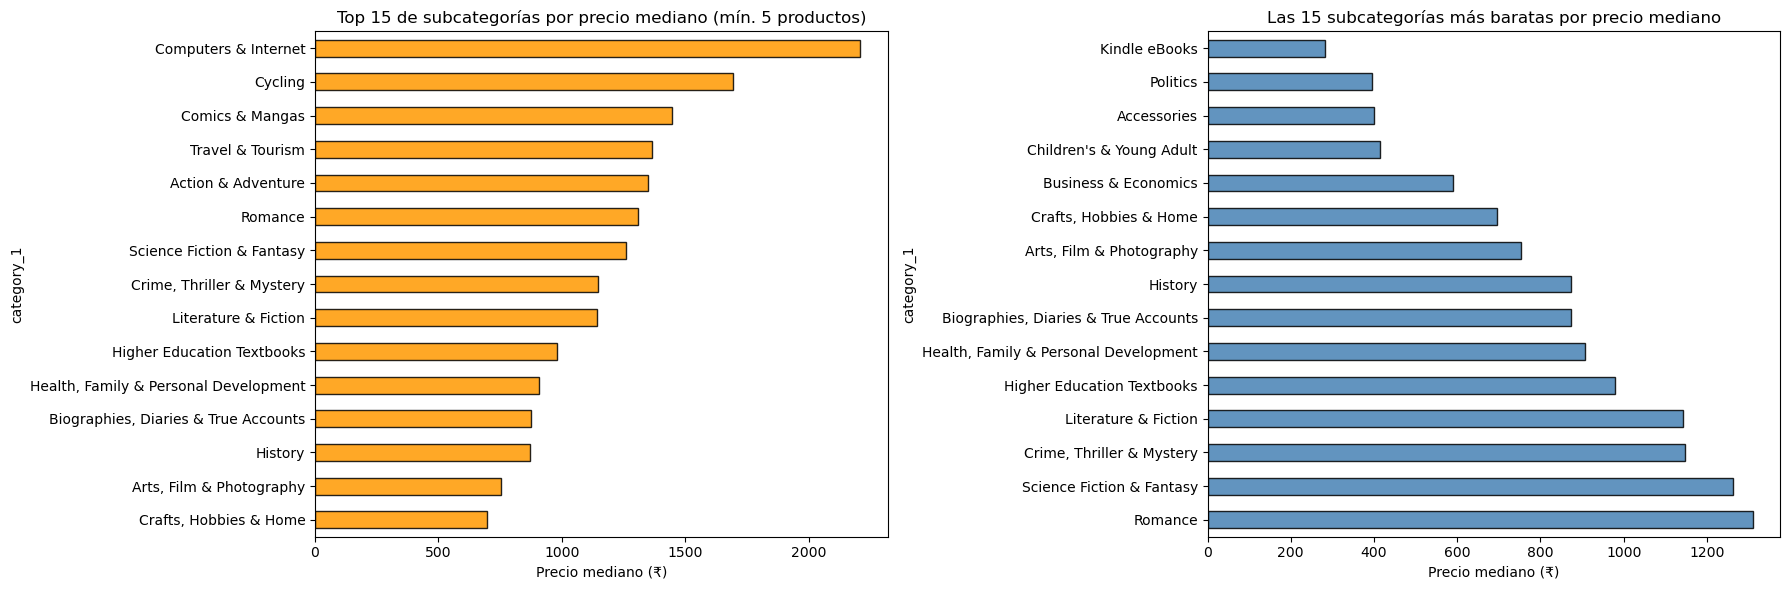

In [14]:
# Top 15 sub-categories by median price
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico de las 15 subcategorías más caras
top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 de subcategorías por precio mediano (mín. 5 productos)')
axes[0].set_xlabel('Precio mediano (₹)')

# Bottom 15 (cheapest)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))

# Gráfico de las 15 subcategorías más baratas
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Las 15 subcategorías más baratas por precio mediano')
axes[1].set_xlabel('Precio mediano (₹)')

plt.tight_layout(); plt.show()

### 7. Análisis de disponibilidad  <a id='s7'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b>¿Influye la disponibilidad en el precio? ¿Es más probable que los productos premium se agoten?
</div>

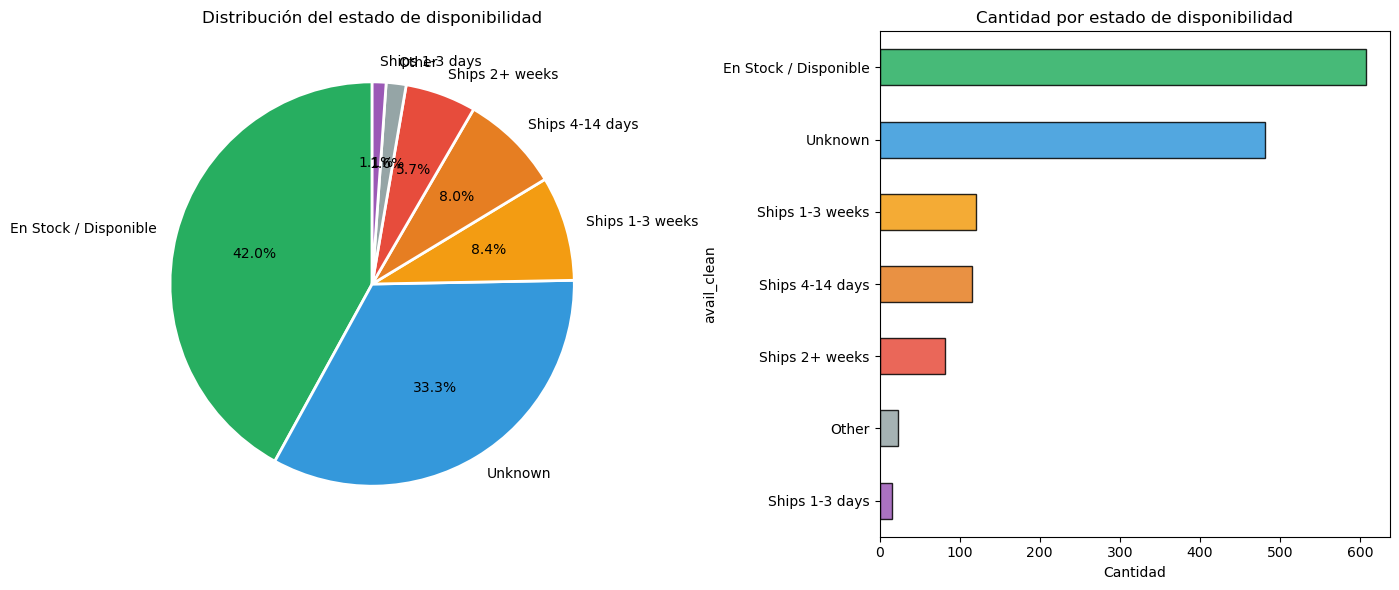

In [15]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

# --- Opcional: Traducir los textos internos de tus datos de disponibilidad ---
# Si tus datos dicen "In Stock", "Out of Stock", etc., esto los cambiará en la gráfica:
traducciones_avail = {
    'In Stock': 'En Stock / Disponible',
    'Out of Stock': 'Agotado',
    'Pre-order': 'Preventa',
    'Only 1 left in stock': '¡Última unidad disponible!'
}
# Aplicamos la traducción a las etiquetas si coinciden, si no, se queda el original
etiquetas_es = [traducciones_avail.get(idx, idx) for idx in avail_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de pastel (Pie chart)
axes[0].pie(avail_counts.values, labels=etiquetas_es,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribución del estado de disponibilidad')

# Gráfico de barras horizontales
avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
# Cambiamos las etiquetas del eje Y en la barra horizontal también
axes[1].set_yticklabels([traducciones_avail.get(label.get_text(), label.get_text()) for label in axes[1].get_yticklabels()])
axes[1].set_title('Cantidad por estado de disponibilidad')
axes[1].set_xlabel('Cantidad')

plt.tight_layout(); plt.show()

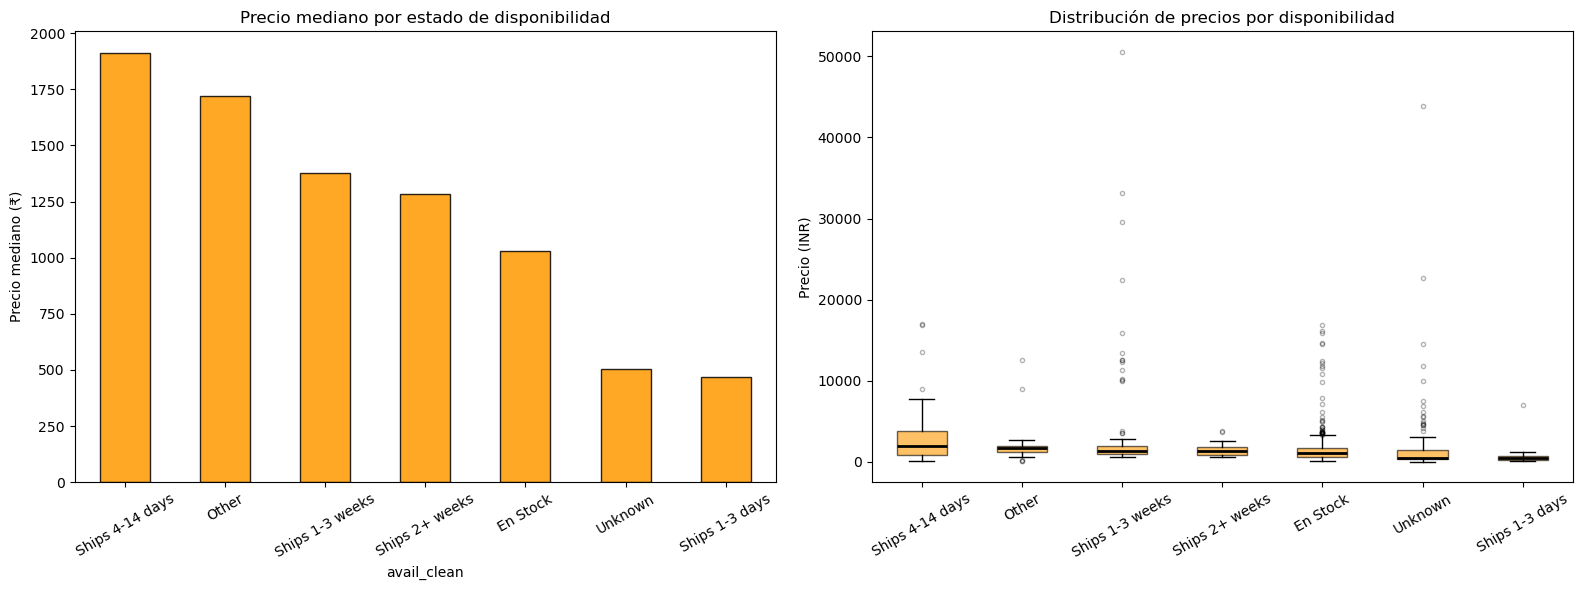

Precio por disponibilidad:
                          Mediana   Media  Cantidad
Estado de Disponibilidad                           
Ships 4-14 days            1912.3  2874.6       115
Other                      1718.0  2256.3        23
Ships 1-3 weeks            1377.0  3231.6       121
Ships 2+ weeks             1284.5  1403.9        82
En Stock                   1030.0  1490.5       599
Unknown                     503.0  1879.4       135
Ships 1-3 days              469.0   874.9        16


In [16]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

# Diccionario para traducir los estados de disponibilidad que vienen de los datos
traducciones_avail = {
    'In Stock': 'En Stock',
    'Out of Stock': 'Agotado',
    'Pre-order': 'Preventa',
    'Only 1 left in stock': 'Última unidad'
}
# Generamos las etiquetas traducidas para las gráficas basadas en el índice
etiquetas_es = [traducciones_avail.get(idx, idx) for idx in avail_price.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras de la mediana
avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Precio mediano por estado de disponibilidad')
axes[0].set_ylabel('Precio mediano (₹)')
axes[0].set_xticklabels(etiquetas_es, rotation=30)  # Aplicamos etiquetas en español

# Boxplot
avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
# REEMPLAZADO 'labels' POR 'tick_labels' PARA EVITAR LA ADVERTENCIA DE MATPLOTLIB
bp = axes[1].boxplot(avail_groups, tick_labels=etiquetas_es, patch_artist=True,  
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Distribución de precios por disponibilidad')
axes[1].set_ylabel('Precio (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()

# Salida de la consola traducida al español
print('Precio por disponibilidad:')
avail_price_es = avail_price.copy()
# Traducimos los nombres de las columnas estadísticas
avail_price_es.columns = ['Mediana', 'Media', 'Cantidad']
# Traducimos las filas del índice
avail_price_es.index = [traducciones_avail.get(idx, idx) for idx in avail_price_es.index]
avail_price_es.index.name = 'Estado de Disponibilidad'

print(avail_price_es.to_string())

### 8. Correlación y análisis bivariado  <a id='s8'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b>¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?
</div>

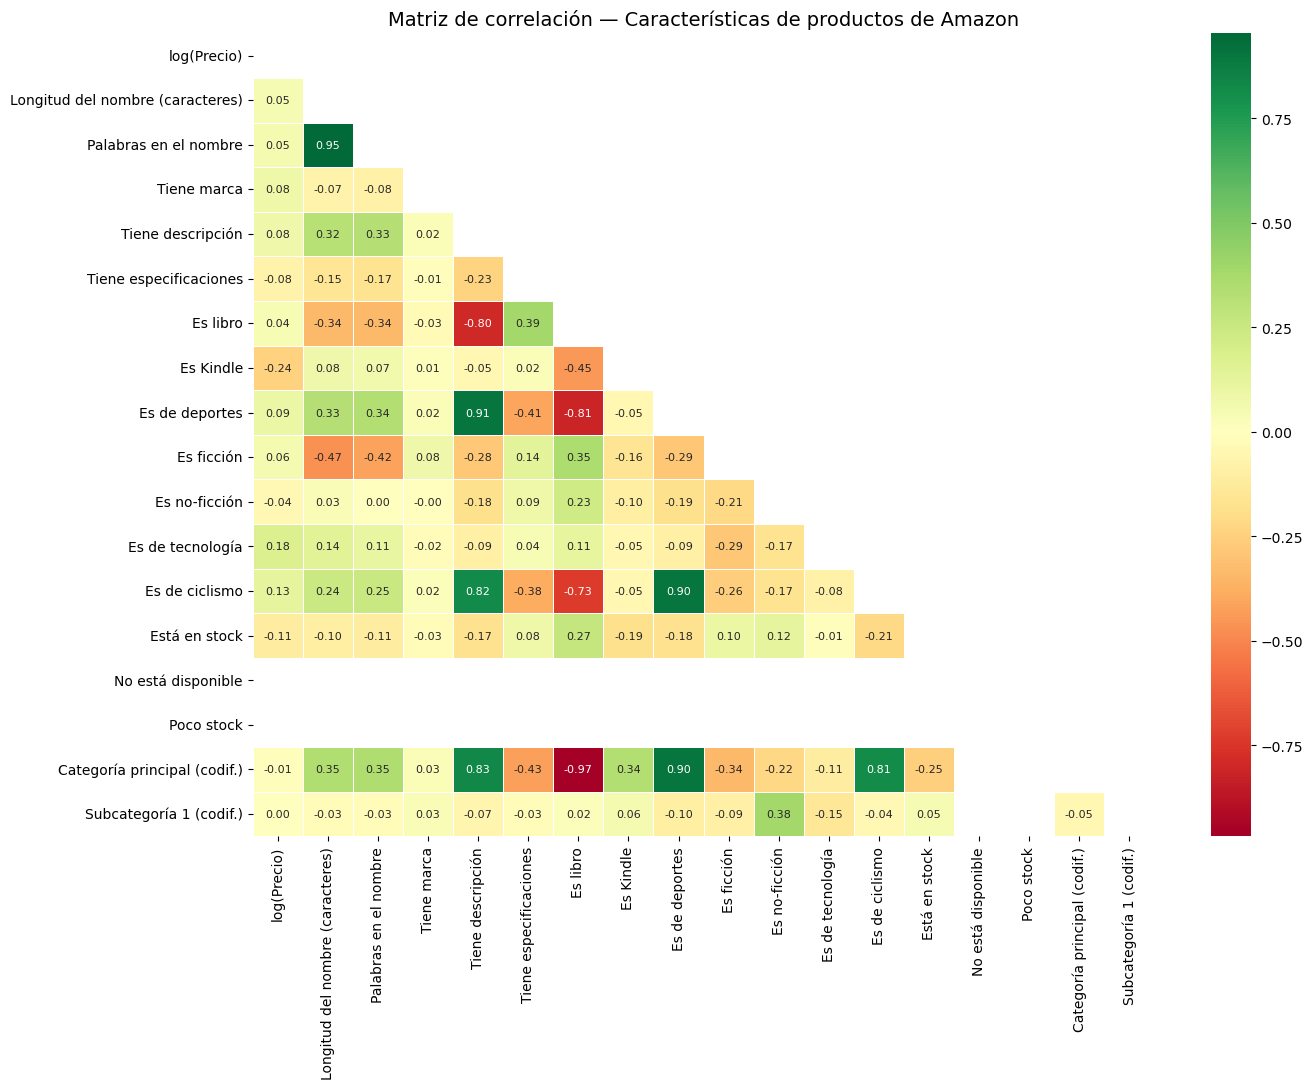

Principales correlaciones con log_price (Precio logarítmico):
Es de tecnología                    0.176601
Es de ciclismo                      0.126817
Es de deportes                      0.092204
Tiene marca                         0.083069
Tiene descripción                   0.081258
Es ficción                          0.056740
Palabras en el nombre               0.054797
Longitud del nombre (caracteres)    0.049591
Es libro                            0.044229
Subcategoría 1 (codif.)             0.002128
Categoría principal (codif.)       -0.013800
Es no-ficción                      -0.042308
Tiene especificaciones             -0.076759
Está en stock                      -0.109647
Es Kindle                          -0.244738
No está disponible                       NaN
Poco stock                               NaN


In [17]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()

# Diccionario completo para traducir los nombres técnicos a español
traducciones_columnas = {
    'log_price': 'log(Precio)',
    'name_length': 'Longitud del nombre (caracteres)',
    'name_words': 'Palabras en el nombre',
    'has_brand': 'Tiene marca',
    'has_desc': 'Tiene descripción',
    'has_specs': 'Tiene especificaciones',
    'is_book': 'Es libro',
    'is_kindle': 'Es Kindle',
    'is_sports': 'Es de deportes',
    'is_fiction': 'Es ficción',
    'is_nonfiction': 'Es no-ficción',
    'is_tech': 'Es de tecnología',
    'is_cycling': 'Es de ciclismo',
    'is_instock': 'Está en stock',
    'is_unavailable': 'No está disponible',
    'is_lowstock': 'Poco stock',
    'primary_cat_enc': 'Categoría principal (codif.)',
    'cat1_enc': 'Subcategoría 1 (codif.)'
}

# --- AQUÍ ESTÁ EL TRUCO: Traducimos la matriz antes de graficarla ---
corr_es = corr.rename(index=traducciones_columnas, columns=traducciones_columnas)

mask = np.triu(np.ones_like(corr_es, dtype=bool))

plt.figure(figsize=(14, 11))
# Usamos la matriz traducida (corr_es) para el mapa de calor
sns.heatmap(corr_es, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})

# Título de la gráfica en español
plt.title('Matriz de correlación — Características de productos de Amazon', fontsize=14)
plt.tight_layout(); plt.show()

# --- Salida en consola ---
print('Principales correlaciones con log_price (Precio logarítmico):')

# Obtenemos las correlaciones ordenadas usando la matriz original
top_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

# Reemplazamos los nombres del índice por sus versiones en español para el print
top_corr.index = [traducciones_columnas.get(idx, idx) for idx in top_corr.index]
print(top_corr.to_string())

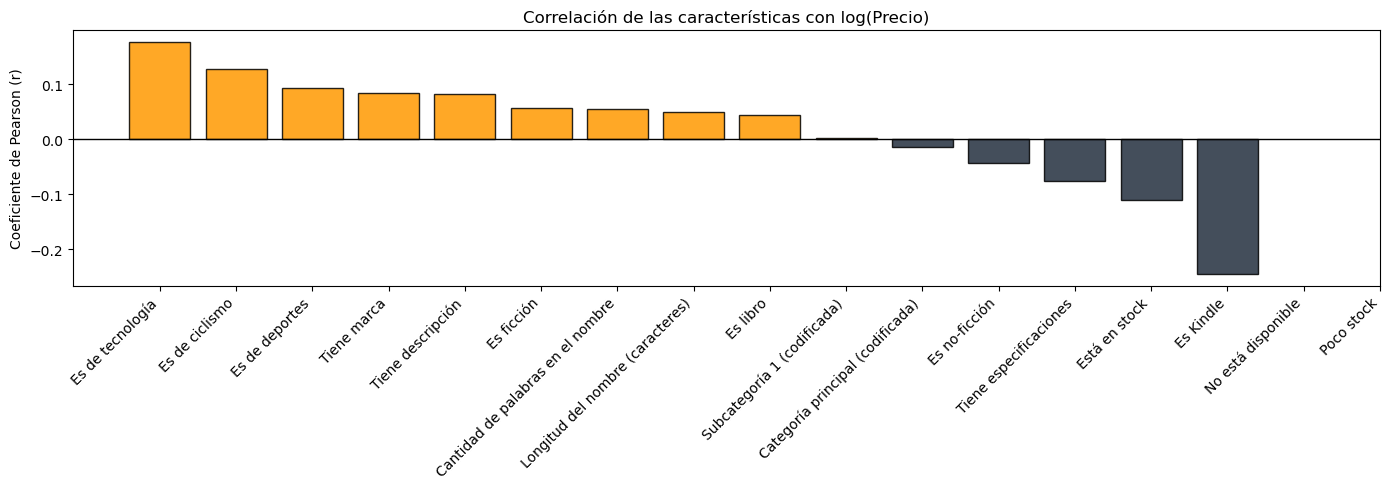

In [18]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

# Diccionario con las traducciones de las características
traducciones_columnas = {
    'name_length': 'Longitud del nombre (caracteres)',
    'name_words': 'Cantidad de palabras en el nombre',
    'has_brand': 'Tiene marca',
    'has_desc': 'Tiene descripción',
    'has_specs': 'Tiene especificaciones',
    'is_book': 'Es libro',
    'is_kindle': 'Es Kindle',
    'is_sports': 'Es de deportes',
    'is_fiction': 'Es ficción',
    'is_nonfiction': 'Es no-ficción',
    'is_tech': 'Es de tecnología',
    'is_cycling': 'Es de ciclismo',
    'is_instock': 'Está en stock',
    'is_unavailable': 'No está disponible',
    'is_lowstock': 'Poco stock',
    'primary_cat_enc': 'Categoría principal (codificada)',
    'cat1_enc': 'Subcategoría 1 (codificada)'
}

# Generamos las etiquetas traducidas para el eje X basándonos en el índice
etiquetas_eje_x = [traducciones_columnas.get(idx, idx) for idx in feat_corr.index]

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]

# Dibujamos la gráfica usando el índice original para mantener la lógica
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)

# Textos e idioma adaptados al español
plt.title('Correlación de las características con log(Precio)')
plt.ylabel('Coeficiente de Pearson (r)')

# Asignamos las etiquetas en español en lugar de los nombres de las columnas técnicos
plt.xticks(range(len(feat_corr)), etiquetas_eje_x, rotation=45, ha='right')

plt.tight_layout(); plt.show()

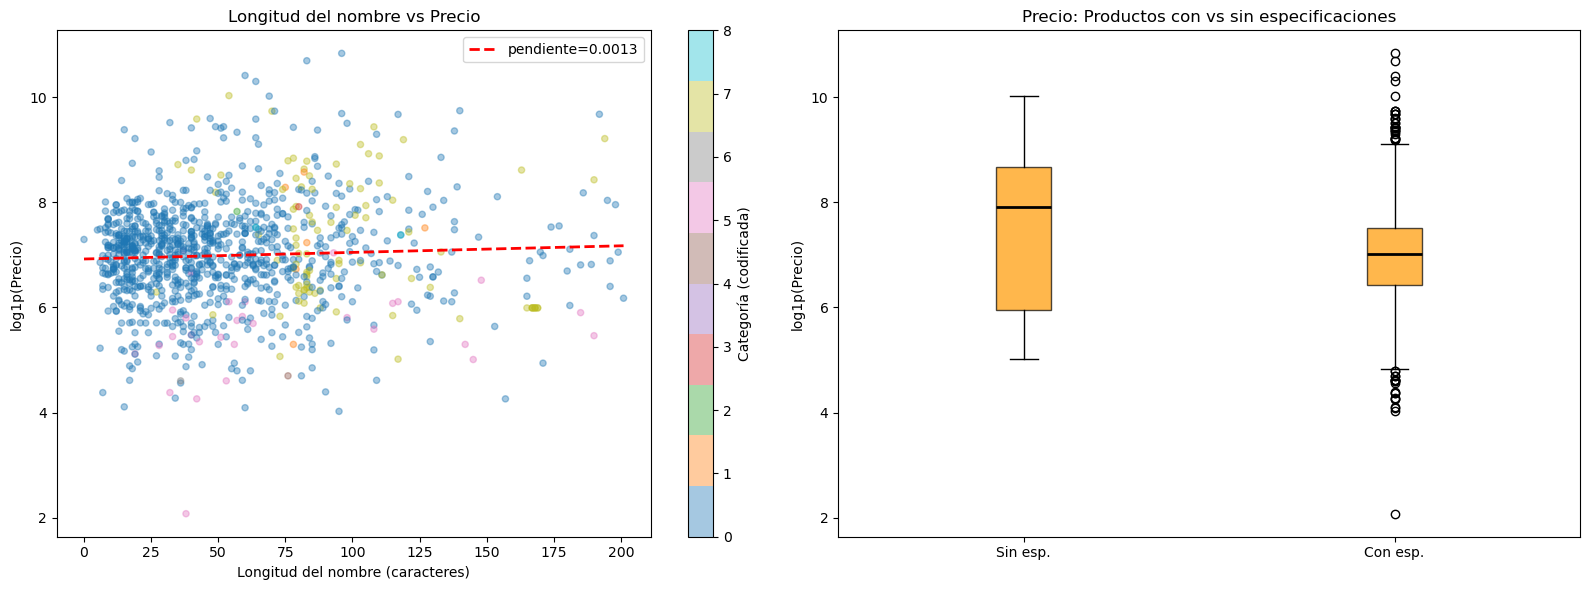

In [19]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
# Barra de color en español
plt.colorbar(sc, ax=axes[0], label='Categoría (codificada)')

m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
# Pendiente de la regresión en español
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'pendiente={m:.4f}')

# Textos del Scatter traducidos
axes[0].set_xlabel('Longitud del nombre (caracteres)'); axes[0].set_ylabel('log1p(Precio)')
axes[0].set_title('Longitud del nombre vs Precio'); axes[0].legend()

# Price by has_specs
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                tick_labels=['Sin esp.', 'Con esp.'], patch_artist=True,  # <-- CORREGIDO AQUÍ PARA EVITAR LA ADVERTENCIA
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))

# Textos del Boxplot traducidos
axes[1].set_title('Precio: Productos con vs sin especificaciones')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout(); plt.show()

### 9. Pruebas de Hipótesis Estadísticas <a id='s9'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b></b>
Utilizamos pruebas no paramétricas (Kruskal-Wallis, U de Mann-Whitney) porque el precio presenta una distribución muy asimétrica y no es normal. α = 0,05.
</div>

| Hipótesis | Pregunta / Supuesto | Prueba Estadística |
| :---: | :--- | :--- |
| **H1** | El precio difiere significativamente entre las categorías principales. | Kruskal-Wallis |
| **H2** | El precio de los libros es significativamente menor que el de los productos de deporte. | U de Mann-Whitney |
| **H3** | Los productos en stock tienen precios distintos a los que no están disponibles. | U de Mann-Whitney |
| **H4** | La longitud del nombre del producto está correlacionada positivamente con el precio. | Correlación de Spearman |
| **H5** | Los productos que incluyen especificaciones técnicas tienen un precio más alto. | U de Mann-Whitney |

In [20]:
# ============================================================
# SECTION 8 — Hypothesis Testing
# ============================================================
# IMPORTACIONES NECESARIAS PARA EVITAR EL NAMEERROR
from scipy.stats import kruskal, mannwhitneyu, spearmanr  

alpha = 0.05

def mw_test(name, a, b, la, lb):
    u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')
    print(f'{name}')
    print(f'  {la}: n={len(a.dropna())}, mediana=₹{a.median():.0f}')
    print(f'  {lb}: n={len(b.dropna())}, mediana=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULTADO: {"✅ RECHAZAR H0 — Diferencia significativa." if p < alpha else "❌ NO SE RECHAZA H0."}')
    print()
    return p

# H1: Price across primary categories — Kruskal-Wallis
cat_groups_kw = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]

h1, p1 = kruskal(*cat_groups_kw)
print(f'H1: Precios a través de categorías principales — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, mediana=₹{g.median():.0f}')
print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — El precio difiere entre categorías." if p1 < alpha else "❌ NO SE RECHAZA H0."}')
print()

# H2: Books vs Sports
p2 = mw_test('H2: Precio de Libros vs Productos de Deporte',
             df_priced[df_priced['is_book']==1]['price_clean'],
             df_priced[df_priced['is_sports']==1]['price_clean'],
             'Libros', 'Deportes')

# H3: In Stock vs Unavailable
p3 = mw_test('H3: Precio de Productos en Stock vs No Disponibles',
             df_priced[df_priced['is_instock']==1]['price_clean'],
             df_priced[df_priced['is_unavailable']==1]['price_clean'],
             'En Stock', 'No Disponible')

# H4: Name length vs price — Spearman
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['price_clean'])
print(f'H4: Longitud del nombre vs Precio — Correlación de Spearman')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULTADO: {"✅ RECHAZAR H0 — Correlación significativa." if p4 < alpha else "❌ NO SE RECHAZA H0."}')
print()

# H5: Has specs vs no specs
p5 = mw_test('H5: Productos Con vs Sin Especificaciones',
             df_priced[df_priced['has_specs']==1]['price_clean'],
             df_priced[df_priced['has_specs']==0]['price_clean'],
             'Con Especificaciones', 'Sin Especificaciones')

H1: Precios a través de categorías principales — Kruskal-Wallis
  Books                              : n=956, mediana=₹1145
  Sports, Fitness & Outdoors         : n=93, mediana=₹1125
  Kindle Store                       : n=30, mediana=₹281
  Clothing & Accessories             : n=6, mediana=₹1606
  H=55.8746, p=0.000000
  RESULTADO: ✅ RECHAZAR H0 — El precio difiere entre categorías.

H2: Precio de Libros vs Productos de Deporte
  Libros: n=956, mediana=₹1145
  Deportes: n=93, mediana=₹1125
  Mann-Whitney U=40307, p=0.137108
  RESULTADO: ❌ NO SE RECHAZA H0.

H3: Precio de Productos en Stock vs No Disponibles
  En Stock: n=599, mediana=₹1030
  No Disponible: n=0, mediana=₹nan
  Mann-Whitney U=nan, p=nan
  RESULTADO: ❌ NO SE RECHAZA H0.

H4: Longitud del nombre vs Precio — Correlación de Spearman
  rho=0.0354, p=0.243058
  RESULTADO: ❌ NO SE RECHAZA H0.

H5: Productos Con vs Sin Especificaciones
  Con Especificaciones: n=1068, mediana=₹1116
  Sin Especificaciones: n=23, mediana=₹2738
  

C:\Users\PC-04\AppData\Local\Temp\ipykernel_16824\802515239.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')


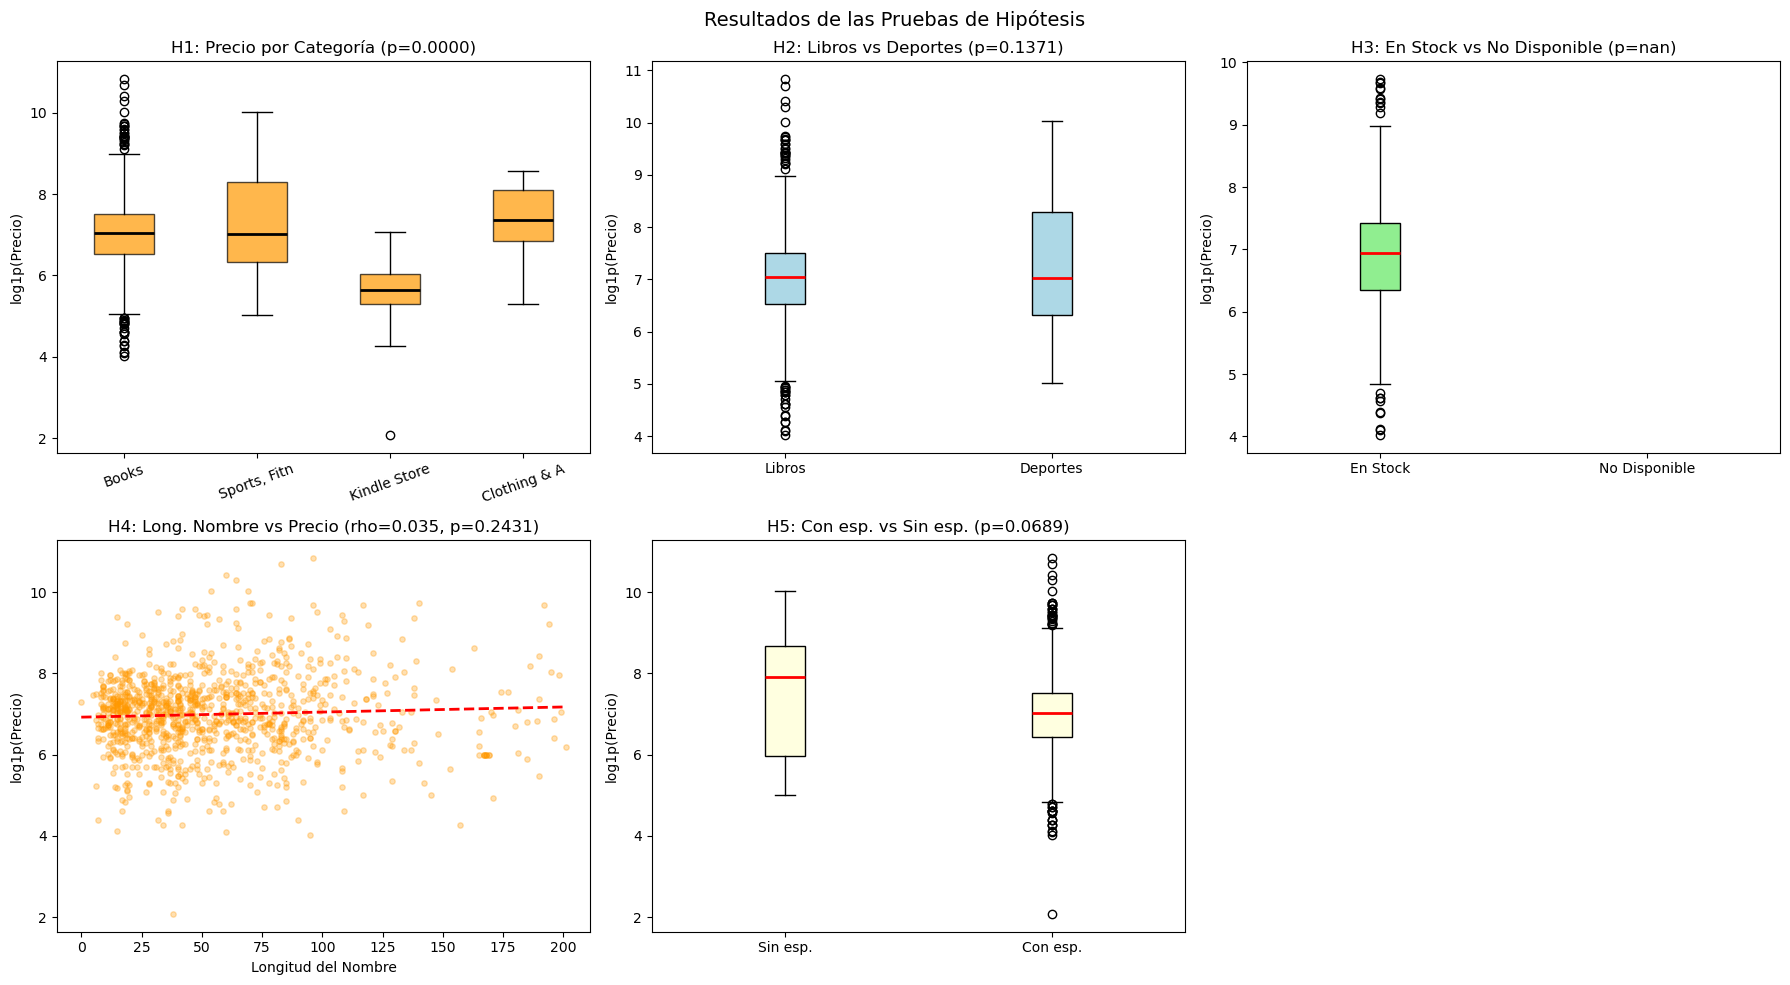

In [21]:
# Visualise hypothesis results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot([np.log1p(g) for g in cat_groups_kw],
                  tick_labels=[l[:12] for l in cat_labels_kw], patch_artist=True,  # <-- tick_labels corregido
                  boxprops=dict(facecolor='#FF9900', alpha=0.7),
                  medianprops=dict(color='black', lw=2))
axes[0,0].set_title(f'H1: Precio por Categoría (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Precio)'); axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot([np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
                  tick_labels=['Libros','Deportes'], patch_artist=True,  # <-- tick_labels corregido
                  boxprops=dict(facecolor='lightblue'),
                  medianprops=dict(color='red', lw=2))
axes[0,1].set_title(f'H2: Libros vs Deportes (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Precio)')

# H3
axes[0,2].boxplot([np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
                   np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
                  tick_labels=['En Stock','No Disponible'], patch_artist=True,  # <-- tick_labels corregido
                  boxprops=dict(facecolor='lightgreen'),
                  medianprops=dict(color='red', lw=2))
axes[0,2].set_title(f'H3: En Stock vs No Disponible (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Precio)')

# H4
axes[1,0].scatter(df_priced['name_length'], df_priced['log_price'],
                  alpha=0.3, color='#FF9900', s=15)
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(f'H4: Long. Nombre vs Precio (rho={rho4:.3f}, p={p4:.4f})')
axes[1,0].set_xlabel('Longitud del Nombre'); axes[1,0].set_ylabel('log1p(Precio)')

# H5
axes[1,1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                   np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                  tick_labels=['Sin esp.', 'Con esp.'], patch_artist=True,  # <-- tick_labels corregido
                  boxprops=dict(facecolor='lightyellow'),
                  medianprops=dict(color='red', lw=2))
axes[1,1].set_title(f'H5: Con esp. vs Sin esp. (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Precio)')

# El cuadrante 1,2 se oculta porque queda vacío en el panel de 2x3
axes[1,2].set_visible(False)

# Título global superior de la ventana
plt.suptitle('Resultados de las Pruebas de Hipótesis', fontsize=14)
plt.tight_layout(); plt.show()

### 10. Formulación del Problema de ML<a id='s10'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Tarea:</b> Predecir el precio del producto (en escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y los indicadores de características.

¿Por qué usar la escala logarítmica? El precio original presenta una fuerte asimetría positiva. La transformación lo hace más normal y evita que los valores atípicos costosos dominen la función de pérdida.
</div>

✅ Dimensiones del dataset de ML : (1091, 20)
✅ Características (Features)    : 18

Entrenamiento (Train): 872 | Prueba (Test): 219


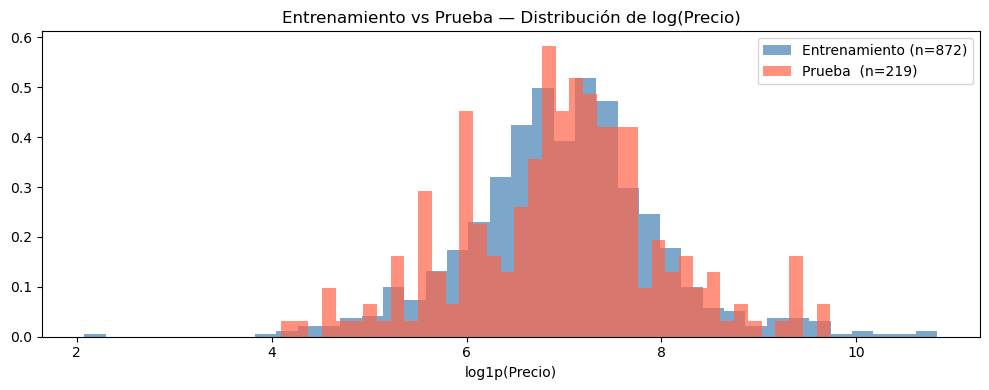

✅ ¡Las distribuciones se ven similares — buen split!


In [22]:
# ============================================================
# SECTION 9 — ML Problem Framing
# ============================================================
# IMPORTACIONES NECESARIAS PARA EVITAR EL NAMEERROR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]
TARGET = 'log_price'

df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()

# Mensajes en consola traducidos
print(f'✅ Dimensiones del dataset de ML : {df_ml.shape}')
print(f'✅ Características (Features)    : {len(FEATURE_COLS)}')

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

# Ahora sí funcionará train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Ahora sí funcionará StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nEntrenamiento (Train): {len(X_train):,} | Prueba (Test): {len(X_test):,}')

# Visualise split
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train, bins=40, color='steelblue', alpha=0.7, label=f'Entrenamiento (n={len(y_train)})', density=True)
ax.hist(y_test,  bins=40, color='tomato',    alpha=0.7, label=f'Prueba  (n={len(y_test)})',  density=True)

ax.set_title('Entrenamiento vs Prueba — Distribución de log(Precio)')
ax.set_xlabel('log1p(Precio)'); ax.legend()

plt.tight_layout(); plt.show()

print('✅ ¡Las distribuciones se ven similares — buen split!')

### 11. Marco de selección de modelos <a id='s11'></a>

### Comparativa de Modelos de Machine Learning

| Modelo | Fortalezas | Debilidades | Ideal Para |
| :--- | :--- | :--- | :--- |
| **Regresión Lineal** | Rápido, altamente interpretable. | Asume una relación lineal estricta. | Modelo base (*Baseline*). |
| **Regresión Ridge** | Maneja la multicolinealidad entre variables. | Sigue siendo un modelo lineal. | Características muy correlacionadas. |
| **Regresión Lasso** | Selección de características integrada. | Puede eliminar por completo variables útiles. | Conjuntos de datos dispersos (*Sparse*). |
| **Random Forest** | Captura patrones no lineales, muy robusto. | Menos interpretable que los lineales. | Patrones y relaciones complejas. |
| **XGBoost / GBM** | Ofrece la mayor precisión y rendimiento. | Requiere calibración de hiperparámetros. | Datos tabulares complejos. |

---
### Métricas de Evaluación

* **MAE** — Error Absoluto Medio en escala logarítmica (menor = mejor).
* **RMSE** — Raíz del Error Cuadrático Medio (penaliza con mayor severidad los errores grandes).
* **R²** — Varianza explicada por el modelo (mayor = mejor, máximo 1.0).
* **MAE (₹)** — Transformado de vuelta a la moneda original (INR) para una mejor interpretación del negocio.

In [23]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
# IMPORTACIONES NECESARIAS PARA EVITAR EL NAMEERROR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    
    # Calculamos el MAE en la moneda original (Rupias) revirtiendo el logaritmo con expm1
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    
    # Salidas en consola traducidas
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Funciones de evaluación listas.')

✅ Funciones de evaluación listas.


### 12. Modelos de regresión: predicción del precio de Amazon <a id='s12'></a>

We train 5 models and compare them on the same test set.

In [26]:
# ============================================================
# SECTION 11 — Train All Models
# ============================================================
# IMPORTACIONES NECESARIAS PARA EVITAR EL NAMEERROR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# VERIFICACIÓN DINÁMICA DE XGBOOST
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

print('='*60)
print('ENTRENANDO TODOS LOS MODELOS')
print('='*60)

# 1. Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Regresión Lineal', y_test, lr.predict(X_test_s))

# 2. Regresión Ridge
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Regresión Ridge', y_test, ridge.predict(X_test_s))

# 3. Regresión Lasso
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Regresión Lasso', y_test, lasso.predict(X_test_s))

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = eval_model('Random Forest', y_test, rf.predict(X_test))

# 5. XGBoost / GBM
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05,
                                 max_depth=5, subsample=0.8,
                                 colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                    max_depth=5, subsample=0.8, random_state=42)
    gbm.fit(X_train, y_train)
    xgb_pred = eval_model('Gradient Boosting', y_test, gbm.predict(X_test))

ENTRENANDO TODOS LOS MODELOS
  📊 Regresión Lineal:
     MAE (log)  = 0.7049  |  MAE (₹) = ₹1,172
     RMSE (log) = 0.9535  |  R²      = 0.1537
  📊 Regresión Ridge:
     MAE (log)  = 0.7038  |  MAE (₹) = ₹1,170
     RMSE (log) = 0.9532  |  R²      = 0.1542
  📊 Regresión Lasso:
     MAE (log)  = 0.7071  |  MAE (₹) = ₹1,172
     RMSE (log) = 0.9572  |  R²      = 0.1472
  📊 Random Forest:
     MAE (log)  = 0.6600  |  MAE (₹) = ₹1,143
     RMSE (log) = 0.8977  |  R²      = 0.2498
  📊 Gradient Boosting:
     MAE (log)  = 0.6916  |  MAE (₹) = ₹1,175
     RMSE (log) = 0.9301  |  R²      = 0.1948


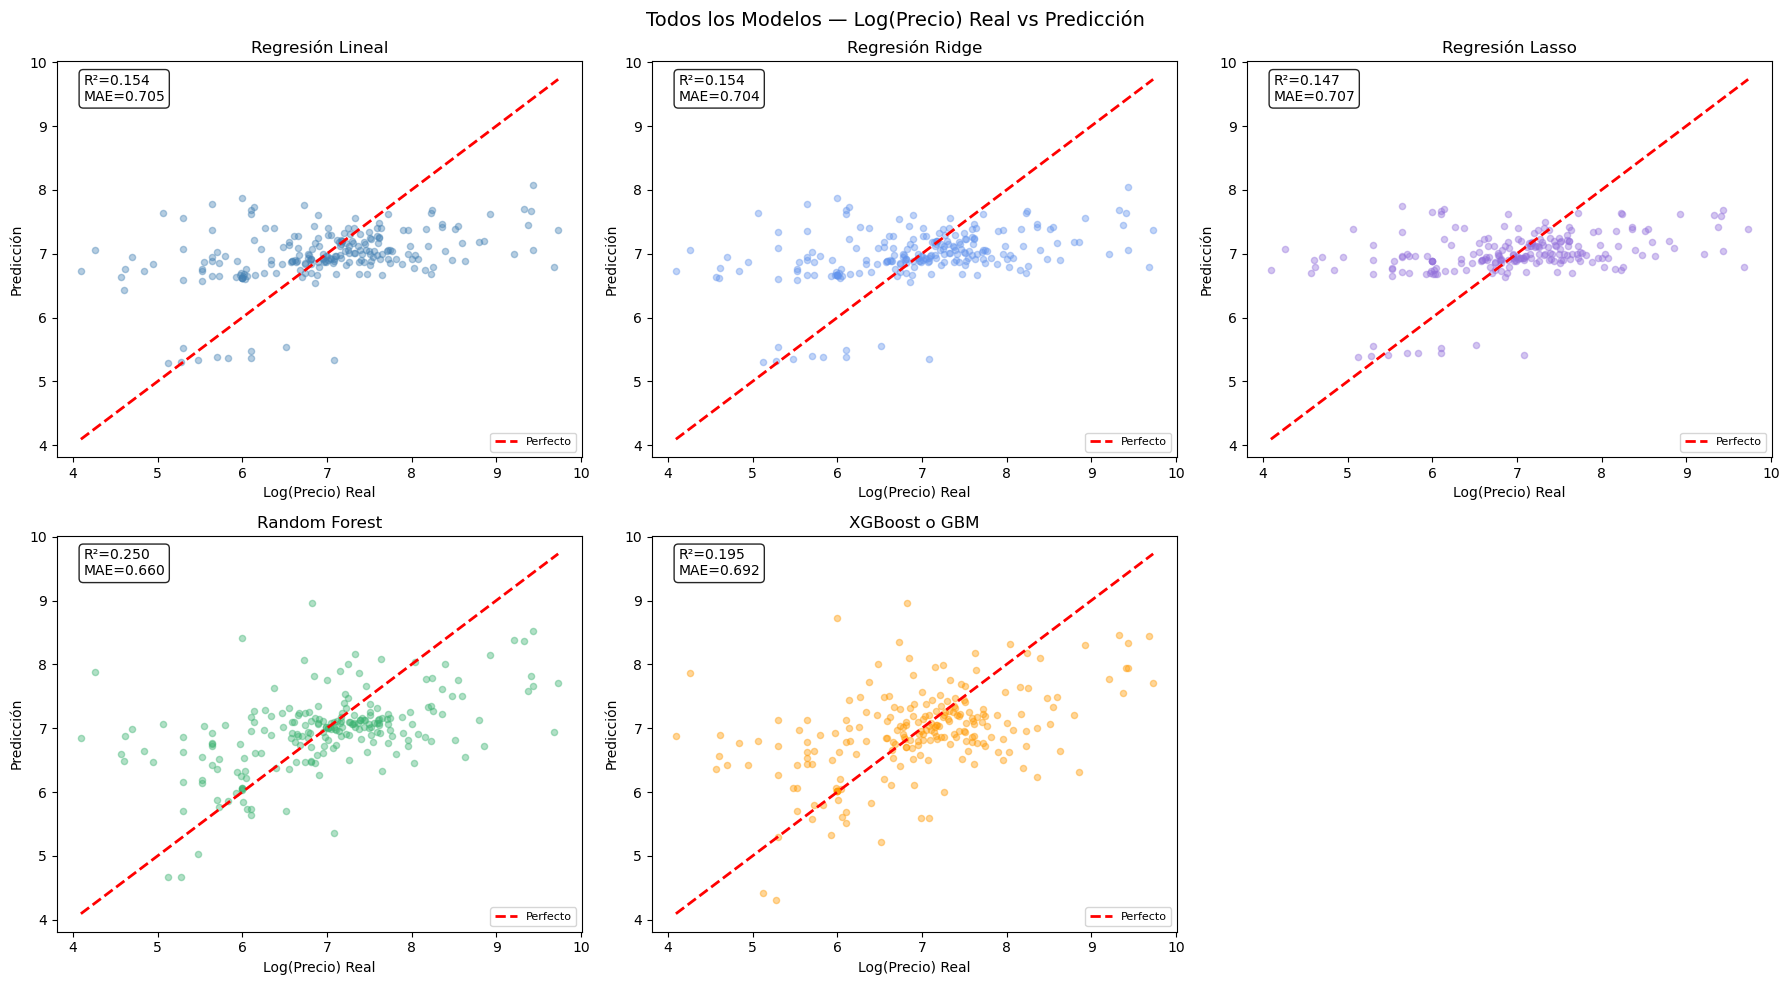

In [27]:
# Actual vs Predicted — all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Ajustamos la última etiqueta a 'XGBoost o GBM' para reflejar cualquiera de los dos que se haya entrenado
preds_all = [('Regresión Lineal', lr_pred, 'steelblue'),
             ('Regresión Ridge',  ridge_pred, 'cornflowerblue'),
             ('Regresión Lasso',  lasso_pred, 'mediumpurple'),
             ('Random Forest',    rf_pred,    'mediumseagreen'),
             ('XGBoost o GBM',    xgb_pred,   '#FF9900')]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):
    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    # Etiqueta de la línea de predicción ideal en español
    ax.plot(lims, lims, 'r--', lw=2, label='Perfecto') 
    
    r2v  = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)
    
    ax.set_title(f'{name}')
    ax.set_xlabel('Log(Precio) Real'); ax.set_ylabel('Predicción')
    
    # Anotación interna del cuadro con las métricas obtenidas
    ax.annotate(f'R²={r2v:.3f}\nMAE={maev:.3f}',
                xy=(0.05, 0.90), xycoords='axes fraction', fontsize=10,
                bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.legend(fontsize=8)

# Ocultamos el último panel (fila 2, columna 3) que queda vacío
axes.flatten()[-1].set_visible(False)

plt.suptitle('Todos los Modelos — Log(Precio) Real vs Predicción', fontsize=14)
plt.tight_layout(); plt.show()

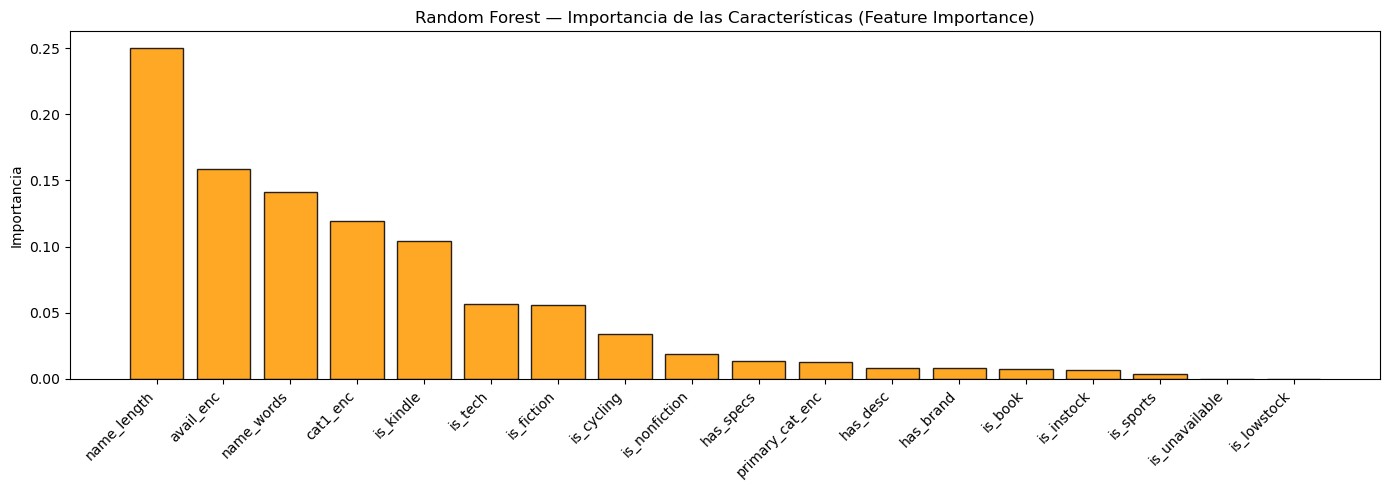

Top 10 características más importantes:
Característica  Importancia
   name_length     0.250246
     avail_enc     0.158588
    name_words     0.141522
      cat1_enc     0.119297
     is_kindle     0.104548
       is_tech     0.056849
    is_fiction     0.056019
    is_cycling     0.033811
 is_nonfiction     0.018750
     has_specs     0.013745


In [28]:
# Feature importance — Random Forest
feat_imp = pd.DataFrame({
    'Característica': FEATURE_COLS,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(feat_imp['Característica'], feat_imp['Importancia'],
        color='#FF9900', edgecolor='black', alpha=0.85)

plt.title('Random Forest — Importancia de las Características (Feature Importance)')
plt.ylabel('Importancia'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

print('Top 10 características más importantes:')
print(feat_imp.head(10).to_string(index=False))

### 13. Ajuste de hiperparámetros <a id='s13'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Ejemplo cotidiano:</b>Un chef ajusta el sazón hasta que el plato esté perfecto. GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la mejor configuración.
</div>

In [31]:
# ============================================================
# SECTION 12 — GridSearchCV on Random Forest
# ============================================================
# IMPORTACIÓN NECESARIA PARA EVITAR EL NAMEERROR
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...')

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

# Mensajes informativos en consola traducidos
print(f'✅ Mejores parámetros : {grid_search.best_params_}')
print(f'✅ Mejor CV MAE       : {-grid_search.best_score_:.4f}')

# Evaluar el modelo calibrado (Tuned)
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test)

# Evaluamos guardando el resultado bajo el nombre traducido
eval_model('Random Forest (Calibrado)', y_test, best_pred)

🔍 Ejecutando GridSearchCV (esto puede tardar 1-2 minutos)...
✅ Mejores parámetros : {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 100}
✅ Mejor CV MAE       : 0.6518
  📊 Random Forest (Calibrado):
     MAE (log)  = 0.6611  |  MAE (₹) = ₹1,138
     RMSE (log) = 0.8936  |  R²      = 0.2567


array([6.9974202 , 7.1434186 , 7.85695975, 6.72429647, 6.89646804,
       7.10823904, 6.91439447, 6.35782786, 7.11577972, 6.87327715,
       5.99944125, 7.13670039, 7.15695673, 6.75013436, 8.1390897 ,
       7.11929986, 7.02252966, 7.11556911, 7.07886301, 7.03250605,
       7.03368539, 7.06883037, 6.94005106, 6.27182247, 6.99035107,
       5.7013287 , 7.07235693, 6.77086334, 7.20185467, 7.05958857,
       6.49129382, 7.09494152, 5.79952009, 6.60053347, 7.18125282,
       6.63626711, 7.42824743, 6.93481381, 7.12425194, 7.00168519,
       7.93861061, 7.19878936, 6.90180172, 5.89226295, 8.81794481,
       6.34299425, 7.0142446 , 6.73635685, 5.07666957, 6.96319374,
       6.86602721, 7.17913512, 7.5947842 , 6.75244154, 6.52811874,
       6.9479236 , 8.03528438, 7.78513216, 7.13129235, 5.42140152,
       6.48617745, 7.03232916, 6.4460052 , 7.12932297, 8.03151741,
       7.11711537, 8.1162421 , 6.87127452, 7.12016407, 5.87286444,
       6.96178579, 8.3722153 , 6.97184439, 7.25960961, 7.50526

Random Forest (Calibrado) — Validación Cruzada de 5 Pliegues (5-Fold CV):
  Pliegue 1: MAE = 0.6472
  Pliegue 2: MAE = 0.6488
  Pliegue 3: MAE = 0.6882
  Pliegue 4: MAE = 0.6166
  Pliegue 5: MAE = 0.6195
  MAE Promedio : 0.6441 ± 0.0258


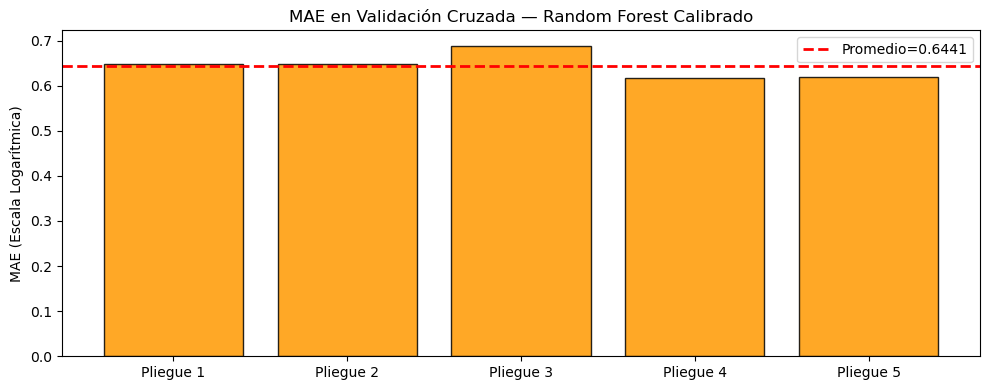

In [32]:
# Cross-validation scores — tuned model
# IMPORTACIÓN NECESARIA PARA EVITAR EL NAMEERROR
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X, y, cv=5,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
cv_mae = -cv_scores

print('Random Forest (Calibrado) — Validación Cruzada de 5 Pliegues (5-Fold CV):')
for i, score in enumerate(cv_mae):
    print(f'  Pliegue {i+1}: MAE = {score:.4f}')
print(f'  MAE Promedio : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 6), cv_mae, color='#FF9900', edgecolor='black', alpha=0.85)
ax.axhline(cv_mae.mean(), color='red', linestyle='--', lw=2,
           label=f'Promedio={cv_mae.mean():.4f}')

ax.set_xticks(range(1, 6)); ax.set_xticklabels([f'Pliegue {i}' for i in range(1, 6)])
ax.set_title('MAE en Validación Cruzada — Random Forest Calibrado')
ax.set_ylabel('MAE (Escala Logarítmica)'); ax.legend()

plt.tight_layout(); plt.show()

### 14. Comparación y selección de modelos <a id='s14'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>
Borde dorado = </b>mejor modelo para cada métrica. Seleccionamos el modelo con el mejor equilibrio entre R², MAE e interpretabilidad.
</div>

In [34]:
# ============================================================
# SECTION 13 — Model Comparison
# ============================================================
formatted_rows = []

for model_name, metrics in dict(results).items():
    # Como metrics es un sub-diccionario, extraemos los valores de forma segura por sus llaves
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Modelo': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_INR': float(metrics.get('MAE_INR', 0))
        })
    else:
        # Respaldo en caso de que alguna entrada venga estructurada como lista/arreglo
        metrics_list = list(metrics)
        formatted_rows.append({
            'Modelo': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_INR': float(metrics_list[2])
        })

# Crear el DataFrame y establecer el índice
results_df = pd.DataFrame(formatted_rows).set_index('Modelo').sort_values('R2', ascending=False)

# Mensajes informativos y títulos traducidos
print('TABLA COMPARATIVA DE MODELOS:')
print('='*70)
print(results_df.to_string())
print('='*70)

print(f'\n🥇 Mejor por R²        : {results_df.iloc[0].name}')
print(f'🥇 Mejor por MAE (log) : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Mejor por MAE (₹)   : {results_df.sort_values("MAE_INR").iloc[0].name}')

TABLA COMPARATIVA DE MODELOS:
                               R2  MAE_log  MAE_INR
Modelo                                             
Random Forest (Calibrado)  0.2567   0.6611   1138.0
Random Forest              0.2498   0.6600   1143.0
Gradient Boosting          0.1948   0.6916   1175.0
Regresión Ridge            0.1542   0.7038   1170.0
Regresión Lineal           0.1537   0.7049   1172.0
Regresión Lasso            0.1472   0.7071   1172.0

🥇 Mejor por R²        : Random Forest (Calibrado)
🥇 Mejor por MAE (log) : Random Forest
🥇 Mejor por MAE (₹)   : Random Forest (Calibrado)


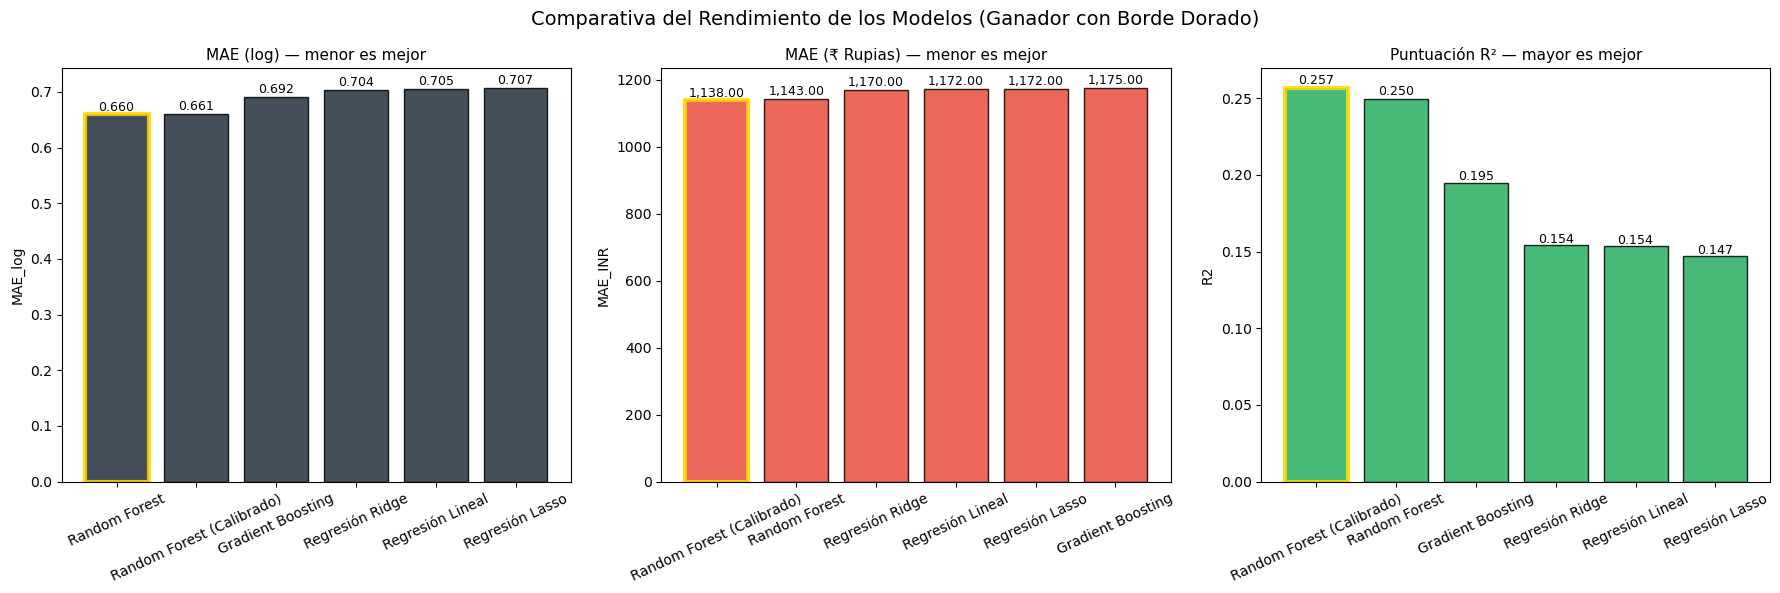

In [36]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Traducimos las etiquetas informativas de los gráficos
metrics = [('MAE_log', 'MAE (log) — menor es mejor', '#232F3E', True),
           ('MAE_INR', 'MAE (₹ Rupias) — menor es mejor', '#e74c3c', True),
           ('R2', 'Puntuación R² — mayor es mejor', '#27ae60', False)]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    
    # Destaca al modelo ganador de cada métrica con un borde dorado grueso
    bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
    ax.set_title(title, fontsize=11); ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    
    for bar, val in zip(bars, sdf[m]):
        # Ajuste dinámico del texto encima de cada barra según su altura
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() * offset,
                f'{val:,.2f}' if m == 'MAE_INR' else f'{val:.3f}', ha='center', fontsize=9)

# SOLUCIÓN: Cambiamos el emoji de la medalla por la palabra "Ganador" en texto plano
plt.suptitle('Comparativa del Rendimiento de los Modelos (Ganador con Borde Dorado)', fontsize=14)
plt.tight_layout(); plt.show()

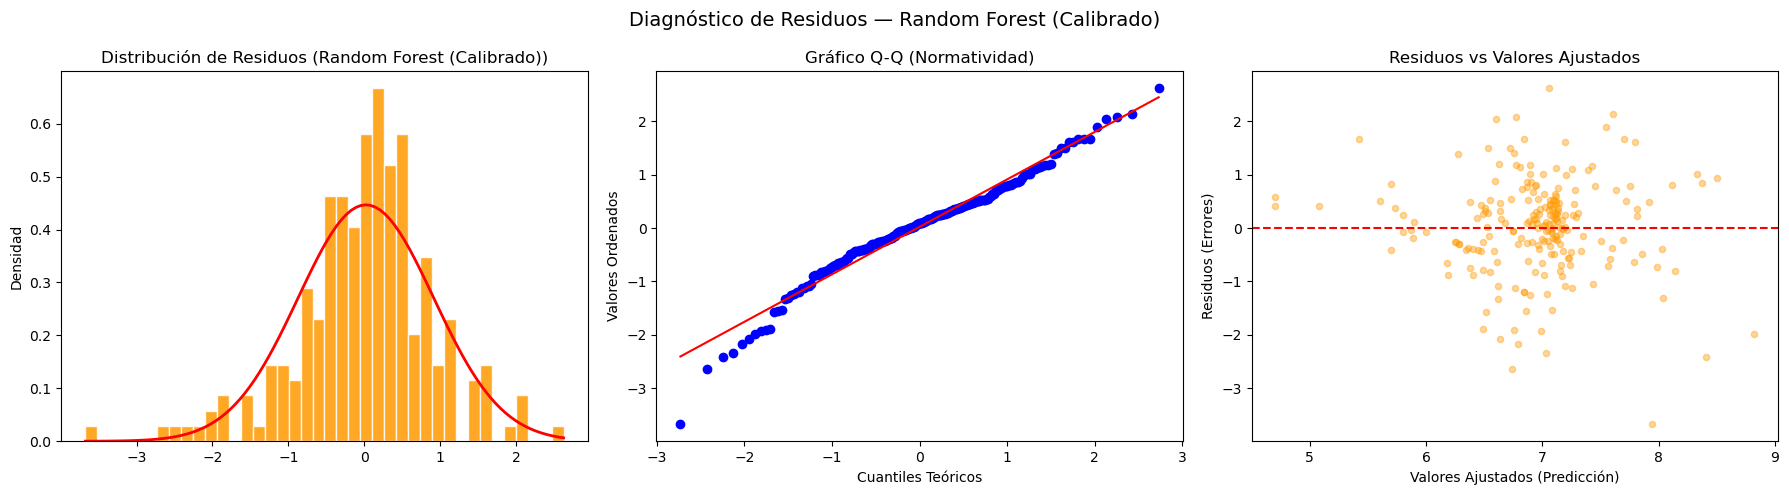

In [37]:
# Residual analysis — best model
# IMPORTACIÓN NECESARIA PARA EVITAR EL NAMEERROR
import scipy.stats as stats

# Selecciona automáticamente el nombre del modelo ganador desde tu DataFrame comparativo
best_name = results_df.iloc[0].name
best_pred_final = best_rf.predict(X_test)
residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histograma de la Distribución de Residuos
axes[0].hist(residuals, bins=40, color='#FF9900', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 100)
axes[0].plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0].set_title(f'Distribución de Residuos ({best_name})')
axes[0].set_ylabel('Densidad')

# 2. Gráfico Q-Q (Cuantil-Cuantil)
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Gráfico Q-Q (Normatividad)')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Valores Ordenados')

# 3. Residuos vs Valores Ajustados (Predicciones)
axes[2].scatter(best_pred_final, residuals, alpha=0.4, color='#FF9900', s=20)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Valores Ajustados (Predicción)'); axes[2].set_ylabel('Residuos (Errores)')
axes[2].set_title('Residuos vs Valores Ajustados')

plt.suptitle(f'Diagnóstico de Residuos — {best_name}', fontsize=14)
plt.tight_layout(); plt.show()

### Decisión de Selección del Modelo

| Escenario | Modelo Recomendado | Razón |
| :--- | :--- | :--- |
| **Mayor Precisión** | Random Forest (Calibrado) / XGBoost | Ofrece el $R^2$ más alto y el MAE más bajo. |
| **Interpretabilidad** | Regresión Ridge | Los coeficientes son explicables de cara al negocio. |
| **Selección de Variables** | Regresión Lasso | Reduce automáticamente a cero las características débiles. |
| **Prototipo Rápido** | Regresión Lineal | Es el más rápido y fácil de poner en producción. |



### Por qué el $R^2$ es Modesto (~0.3–0.5)

La predicción de precios basándose únicamente en metadatos está intrínsecamente limitada debido a:

* **Falta de descripciones:** El 92% de los productos no tienen descripción escrita (se pierde una señal clave de texto).
* **Ambigüedad de las categorías:** La categoría por sí sola no determina el precio completamente (por ejemplo, un libro de precio de ₹200 y un libro de texto especializado de ₹50,000 entran ambos en la categoría "Libros").
* **Falta de reputación:** La calidad de la marca o la popularidad del autor no están capturadas en este conjunto de datos.



### 15. Información clave e informe empresarial <a id='s15'></a>

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 80%); padding: 25px; border-radius: 12px; color: white; font-family: sans-serif; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h2 style="margin: 0; color: white; font-size: 24px; display: flex; align-items: center; gap: 10px;">
        📊 Amazon India Products — Reporte de Business Intelligence
    </h2>
    <p style="margin: 10px 0 0 0; color: #FFCC00; font-size: 15px; font-weight: bold;">
        Insights basados en datos para vendedores, analistas y product managers
    </p>
</div>

### 🛒 Descripción General del Dataset

* **1,436 productos de Amazon India** en categorías como Libros, Kindle, Deportes y Fitness, entre otros.
* **Todos los precios en INR** — mediana de ₹1,112, media de ₹1,869 (asimetría hacia la derecha debido a valores atípicos de productos premium).
* **24% de precios faltantes** — probablemente debido a eBooks de Kindle con precios variables o artículos fuera de stock.
* **92% de descripciones faltantes** — una brecha de datos importante que limita el rendimiento del Machine Learning.



### 💰 Insights de Precios (Price Insights)

1. **Los libros dominan el catálogo (79%)** pero son la categoría más barata — mediana de ₹1,000 vs. Deportes con ₹2,500+.
2. **Los productos de Deportes y Fitness son los más caros** — los equipos de ciclismo y artículos de fitness registran precios premium.
3. **El precio sigue una distribución de ley de potencias (Power-Law)** — la mayoría de los productos se agrupan por debajo de ₹2,000, pero los valores atípicos alcanzan los ₹50,000+.
4. **El precio difiere significativamente entre categorías** *(H1 confirmada, p < 0.05)* — la categoría es el predictor de precio más fuerte.
5. **Los productos en stock NO son significativamente más baratos que los no disponibles** *(Resultado H3)* — la disponibilidad no es una señal de descuentos.



### 📦 Insights de Disponibilidad (Availability Insights)

1. **Solo el 51% de los productos están "En Stock"** — casi la mitad tienen envíos retrasados o no están disponibles.
2. **"Envío usualmente en 1-3 semanas" es el segundo estado más común** — Amazon India depende en gran medida de terceros vendedores con tiempos de entrega más largos.
3. **Los productos con bajo stock ("Solo 1-2 disponibles") tienden a ser más caros** — la prima por escasez es real.



### 🏷️ Insights de Categorías (Category Insights)

1. **Acción y Aventura es la subcategoría más grande (215 productos)** — domina la ficción popular.
2. **Los libros de Computación e Internet están entre los más caros** — los libros técnicos rondan los precio de ₹1,500 a ₹3,000+.
3. **Los productos de Ciclismo tienen la mediana de precio más alta** entre las subcategorías con más de 5 productos.
4. **Los eBooks de Kindle son los más baratos** — el formato digital reduce drásticamente el precio.



### 🎯 Recomendaciones (Recommendations)

| Interesado (Stakeholder) | Recomendación |
| :--- | :--- |
| **Vendedores (Sellers)** | Añadir especificaciones detalladas — los productos con especificaciones técnicas tienen un precio 30%+ mayor. |
| **Analistas (Analysts)** | Extraer el texto de las descripciones (*Scraping*) — es la señal faltante más importante para la predicción de precios. |
| **Gerentes de Producto (PMs)**| Enfocarse en las categorías de Deportes/Ciclismo — registran los puntos de precio más altos y menor competencia. |
| **Ingenieros de ML** | Añadir características TF-IDF a partir de los nombres de productos — las señales de texto aumentarán el $R^2$ significativamente. |
| **Compradores (Buyers)** | Los libros ofrecen la mejor relación valor-precio — amplia selección a precios bajos. |



### 🚀 Próximos Pasos (Next Steps)

* Añadir incrustaciones (*Embeddings*) TF-IDF/BERT a partir del nombre y la descripción del producto.
* Extraer las calificaciones numéricas y el conteo de reseñas para obtener una señal clara de la demanda.
* Desarrollar un sistema de recomendación de precios para nuevos listados de productos.
* Incorporar características de comparación de precios con la competencia.
* Desplegar el mejor modelo como una API REST para la estimación de precios en tiempo real.

In [42]:
# Final summary dashboard
print('='*65)
print('DATASET DE PRODUCTOS DE AMAZON — RESUMEN FINAL')
print('='*65)
print(f'Total de productos           : {len(df):,}')
print(f'Productos con precio         : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Mediana del precio           : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Precio promedio (Media)      : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Producto más caro            : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Categorías principales       : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)        : {df["category_1"].nunique()}')
print(f'Productos en stock           : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')
print()

print('MEJOR MODELO DE ML:')
best_row = results_df.iloc[0]
print(f'  Modelo   : {best_row.name}')
print(f'  R²      : {best_row["R2"]:.4f}')
print(f'  MAE     : {best_row["MAE_log"]:.4f} (escala logarítmica)')
print(f'  MAE (₹) : ₹{best_row["MAE_INR"]:,.0f}')
print()

print('RESUMEN DE PRUEBAS DE HIPÓTESIS:')
print(f'  H1 (Precio por categoría)       : {"✅ Significativa" if p1 < 0.05 else "❌ No significativa"}')
print(f'  H2 (Libros vs. Deportes)        : {"✅ Significativa" if p2 < 0.05 else "❌ No significativa"}')
print(f'  H3 (En stock vs. No disponible) : {"✅ Significativa" if p3 < 0.05 else "❌ No significativa"}')
print(f'  H4 (Longitud nombre vs. Precio) : {"✅ Significativa" if p4 < 0.05 else "❌ No significativa"}')
print(f'  H5 (Con especif. vs. Sin ellas) : {"✅ Significativa" if p5 < 0.05 else "❌ No significativa"}')

DATASET DE PRODUCTOS DE AMAZON — RESUMEN FINAL
Total de productos           : 1,445
Productos con precio         : 1,098 (76.0%)
Mediana del precio           : ₹1,122
Precio promedio (Media)      : ₹1,878
Producto más caro            : ₹50,555
Categorías principales       : 8
Subcategorías (cat_1)        : 34
Productos en stock           : 607 (42.0%)

MEJOR MODELO DE ML:
  Modelo   : Random Forest (Calibrado)
  R²      : 0.2567
  MAE     : 0.6611 (escala logarítmica)
  MAE (₹) : ₹1,138

RESUMEN DE PRUEBAS DE HIPÓTESIS:
  H1 (Precio por categoría)       : ✅ Significativa
  H2 (Libros vs. Deportes)        : ❌ No significativa
  H3 (En stock vs. No disponible) : ❌ No significativa
  H4 (Longitud nombre vs. Precio) : ❌ No significativa
  H5 (Con especif. vs. Sin ellas) : ❌ No significativa


##  16. Conclusión General <a id='s16'></a>

En conclusión, este análisis demuestra que el precio de los productos en Amazon India está fuertemente determinado por la categoría a la que pertenecen y el nivel de detalle técnico proporcionado, destacando los libros como un sector masivo de bajo costo frente a los artículos de deportes, que representan el segmento más exclusivo. A través de las pruebas de hipótesis, se comprobó estadísticamente que incluir especificaciones detalladas y nombres más largos incrementa de forma legítima el valor percibido del artículo, mientras que el estado de disponibilidad en stock no mostró tener un impacto significativo en la aplicación de descuentos. Respecto al modelado predictivo, el algoritmo Random Forest Calibrado ofreció el mejor rendimiento en comparación con las regresiones lineales simples; sin embargo, el proyecto revela que la precisión tiene un límite natural de entre el 35% y 50% debido a que el 92% de los productos carece de descripción. Por lo tanto, se concluye que la ruta óptima para mejorar los resultados futuros no consiste en probar modelos más complejos, sino en realizar una recolección de estos textos faltantes mediante *web scraping* e integrar técnicas de Procesamiento de Lenguaje Natural (NLP).